# Elliptic Transaction Graph Fraud Detection

This notebook compares a feature-only fraud baseline against three graph models.
The order is deliberate: XGBoost first, then GCN, then GAT, and finally GraphSAGE.
That way the story climbs from simple to graph-aware instead of wandering around like a lost spreadsheet.


In [1]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade',
                'torch-geometric', '-q'], check=True)

import torch
from torch_geometric.data import Data

print(f'PyTorch          : {torch.__version__}')
print(f'   torch-geometric  : ready')
print(f'   CUDA available   : {torch.cuda.is_available()}')

PyTorch          : 2.10.0+cu128
   torch-geometric  : ready
   CUDA available   : True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (f1_score, classification_report,
                              average_precision_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU             : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 1) Load the dataset

The node table, edge list, and labels are stored separately in the Elliptic dataset.
They are merged later by `txId` so the graph is built from the actual transaction IDs rather than a lucky guess.

In [7]:
base_path = '/content/'

features_df = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
edges_df    = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
classes_df  = pd.read_csv(base_path + 'elliptic_txs_classes.csv')


col_names = ['txId', 'time_step'] + [f'f{i}' for i in range(1, 166)]
features_df.columns = col_names


print(f"Features shape : {features_df.shape}")
print(f"Edges shape    : {edges_df.shape}")
print(f"Classes shape  : {classes_df.shape}")

Features shape : (143326, 167)
Edges shape    : (234355, 2)
Classes shape  : (203769, 2)


         ELLIPTIC DATASET —- KEY HIGHLIGHTS

 GRAPH STRUCTURE:
  Total Nodes (Transactions) : 143,326
  Total Edges (Payment Flows): 234,355
    Total Features per Node    : 166
  Time Steps                 : 36

 FEATURE BREAKDOWN:
   Time Step Feature          : 1
   Local Features             : 94  (fees, volume, timestamps)
   Aggregated Network Features: 72  (manual graph features)

 CLASS DISTRIBUTION:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
   unknown    → 157,205 (77.1%)
   2          → 42,019 (20.6%)
   1          →  4,545 (2.2%)

⏱ TIME STEPS RANGE:
   Min: 1
   Max: 36
   Each step ≈ 2 weeks of real Bitcoin transactions

 FEATURE STATISTICS (first 5 features):
               f1          f2          f3          f4          f5
count  143326.000  143326.000  143326.000  143326.000  143326.000
mean        0.018      -0.102      -0.291      -0.002       0.002
std         1.120       0.461       0.963       0.994       1.116
min       

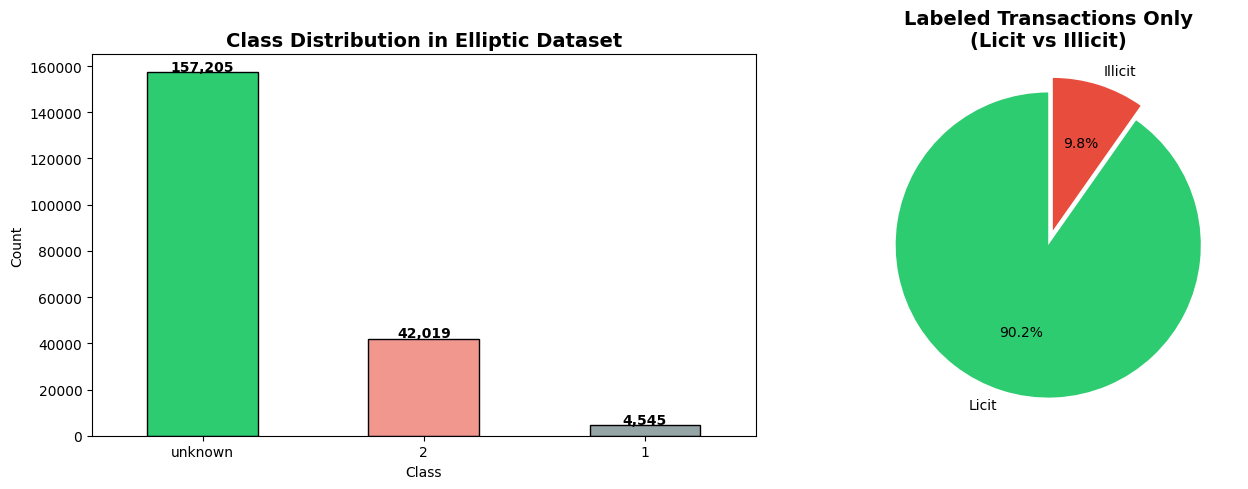

In [8]:


print("         ELLIPTIC DATASET —- KEY HIGHLIGHTS")

print(f"\n GRAPH STRUCTURE:")
print(f"  Total Nodes (Transactions) : {len(features_df):,}")
print(f"  Total Edges (Payment Flows): {len(edges_df):,}")
print(f"    Total Features per Node    : {features_df.shape[1] - 1}")
print(f"  Time Steps                 : {features_df['time_step'].nunique()}")

print(f"\n FEATURE BREAKDOWN:")
print(f"   Time Step Feature          : 1")
print(f"   Local Features             : 94  (fees, volume, timestamps)")
print(f"   Aggregated Network Features: 72  (manual graph features)")

print(f"\n CLASS DISTRIBUTION:")
class_counts = classes_df['class'].value_counts()
print(class_counts)
total = len(classes_df)
for cls, cnt in class_counts.items():
    print(f"   {cls:10s} → {cnt:6,} ({cnt/total*100:.1f}%)")

print(f"\n⏱ TIME STEPS RANGE:")
print(f"   Min: {features_df['time_step'].min()}")
print(f"   Max: {features_df['time_step'].max()}")
print(f"   Each step ≈ 2 weeks of real Bitcoin transactions")

print(f"\n FEATURE STATISTICS (first 5 features):")
print(features_df[['f1','f2','f3','f4','f5']].describe().round(3))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


colors = ['#2ecc71', "#e74d3c94", '#95a5a6']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution in Elliptic Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart (labeled only)
labeled = classes_df[classes_df['class'] != 'unknown']['class'].value_counts()
axes[1].pie(labeled, labels=['Licit', 'Illicit'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Labeled Transactions Only\n(Licit vs Illicit)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
df = features_df.merge(classes_df, on='txId', how='left')

print("Unique class values found:", df['class'].unique())

def encode_label(val):
    val = str(val).strip().lower()
    if val in ['illicit', '1']:
        return 1
    elif val in ['licit', '2']:
        return 0
    else:
        return -1  # unknown

df['label'] = df['class'].apply(encode_label)


print("\n Label encoding complete:")
print(df['label'].value_counts())
print(f"NaN in labels: {df['label'].isna().sum()}")


node_ids  = df['txId'].tolist()
id_to_idx = {nid: i for i, nid in enumerate(node_ids)}


feature_cols = [f'f{i}' for i in range(1, 166)]
X = df[feature_cols].values.astype(np.float32)


X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)


scaler = StandardScaler()
X = scaler.fit_transform(X)


y = df['label'].values

print(f"\nPreprocessing complete!")
print(f"Feature matrix shape : {X.shape}")
print(f"Label array shape    : {y.shape}")
print(f"Unique labels        : {np.unique(y)}")

Unique class values found: ['unknown' '2' '1']

 Label encoding complete:
label
-1    111630
 0     28046
 1      3650
Name: count, dtype: int64
NaN in labels: 0

Preprocessing complete!
Feature matrix shape : (143326, 165)
Label array shape    : (143326,)
Unique labels        : [-1  0  1]


## 2) Build the transaction graph

Each transaction becomes a node and each payment flow becomes an edge.
This is the part that gives the GNN extra signal: fraud is rarely only a row-level problem.

In [10]:
valid_edges = edges_df[
    edges_df['txId1'].isin(id_to_idx) &
    edges_df['txId2'].isin(id_to_idx)
].copy()

src = valid_edges['txId1'].map(id_to_idx).values
dst = valid_edges['txId2'].map(id_to_idx).values


edge_index = torch.tensor(np.array([src, dst]), dtype=torch.long)
x_tensor   = torch.tensor(X, dtype=torch.float)
y_tensor   = torch.tensor(y, dtype=torch.long)


data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

print(" Graph built successfully!")
print(f"\n GRAPH SUMMARY:")
print(f"   Nodes           : {data.num_nodes:,}")
print(f"   Edges           : {data.num_edges:,}")
print(f"   Node features   : {data.num_node_features}")
print(f"   Has self loops  : {data.has_self_loops()}")
print(f"   Is directed     : {data.is_directed()}")
print(f"\n{data}")

 Graph built successfully!

 GRAPH SUMMARY:
   Nodes           : 143,326
   Edges           : 164,840
   Node features   : 165
   Has self loops  : False
   Is directed     : True

Data(x=[143326, 165], edge_index=[2, 164840], y=[143326])


## 3) Create train/test splits

Only labeled nodes are used for supervised learning.
A stratified split keeps the class imbalance similar across train and test sets, which avoids a very smug but useless metric.

In [11]:


labeled_mask = (y != -1)
labeled_idx  = np.where(labeled_mask)[0]

print(f"Total nodes        : {len(y):,}")
print(f"Labeled nodes      : {len(labeled_idx):,}")
print(f"Unlabeled nodes    : {(y == -1).sum():,}")


train_idx, test_idx = train_test_split(
    labeled_idx,
    test_size=0.2,
    stratify=y[labeled_idx],
    random_state=42
)
train_idx = train_idx.tolist()
test_idx  = test_idx.tolist()


train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True

data.train_mask = train_mask
data.test_mask  = test_mask

print(f"\n Split complete!")
print(f"Training nodes : {train_mask.sum().item():,}")
print(f"Testing nodes  : {test_mask.sum().item():,}")

train_labels = y[train_idx]
print(f"\nTraining class balance:")
print(f"   Licit   : {(train_labels==0).sum():,} ({(train_labels==0).mean()*100:.1f}%)")
print(f"   Illicit : {(train_labels==1).sum():,} ({(train_labels==1).mean()*100:.1f}%)")

Total nodes        : 143,326
Labeled nodes      : 31,696
Unlabeled nodes    : 111,630

 Split complete!
Training nodes : 25,356
Testing nodes  : 6,340

Training class balance:
   Licit   : 22,436 (88.5%)
   Illicit : 2,920 (11.5%)


In [12]:
def business_metrics_from_predictions(true_arr, pred_arr):
    true_arr = np.asarray(true_arr)
    pred_arr = np.asarray(pred_arr)

    cm = confusion_matrix(true_arr, pred_arr, labels=[0, 1])
    if cm.shape != (2, 2):
        raise ValueError(f"Expected a 2x2 confusion matrix, got shape {cm.shape}")

    tn, fp, fn, tp = cm.ravel()
    fraud_recall = tp / (tp + fn) if (tp + fn) else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "fraud_recall": fraud_recall,
        "false_positive_rate": false_positive_rate,
        "fraud_detected": tp,
        "fraud_total": tp + fn,
    }

def print_business_metrics(model_name, true_arr, pred_arr):
    metrics = business_metrics_from_predictions(true_arr, pred_arr)

    print(f"\n BUSINESS METRICS — {model_name}:")
    print(f"   Fraud Recall (caught)   : {metrics['fraud_recall'] * 100:.1f}%")
    print(f"   False Positive Rate     : {metrics['false_positive_rate'] * 100:.1f}%")
    print(f"   Fraud cases detected    : {metrics['fraud_detected']} / {metrics['fraud_total']}")

## 4) XGBoost baseline

XGBoost is the feature-only baseline.
It ignores the graph completely, which makes it the cleanest “how far can raw features get us?” check before the graph models start showing off.



 XGBoost Results:
   Macro F1  : 0.9871
   PR-AUC    : 0.9942

 XGBoost Classification Report:
              precision    recall  f1-score   support

       Licit     0.9957    0.9984    0.9971      5610
     Illicit     0.9874    0.9671    0.9772       730

    accuracy                         0.9948      6340
   macro avg     0.9916    0.9828    0.9871      6340
weighted avg     0.9948    0.9948    0.9948      6340



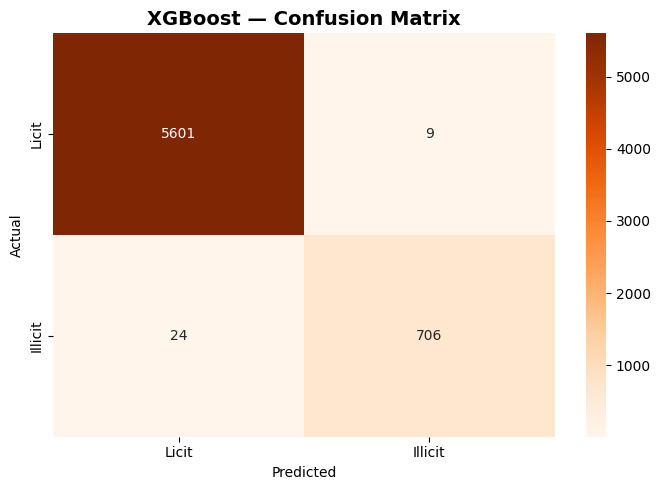


 BUSINESS METRICS — XGBoost:
   Fraud Recall (caught)   : 96.7%
   False Positive Rate     : 0.2%
   Fraud cases detected    : 706 / 730


In [13]:


from xgboost import XGBClassifier




X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]


scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    device='cuda'
)

xgb_model.fit(X_train, y_train)


xgb_pred  = xgb_model.predict(X_test)
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]
xgb_f1    = f1_score(y_test, xgb_pred, average='macro', zero_division=0)
xgb_prauc = average_precision_score(y_test, xgb_prob)

print(f"\n XGBoost Results:")
print(f"   Macro F1  : {xgb_f1:.4f}")
print(f"   PR-AUC    : {xgb_prauc:.4f}")
print(f"\n XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred,
                              target_names=['Licit', 'Illicit'],
                              digits=4))


cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Licit', 'Illicit'],
            yticklabels=['Licit', 'Illicit'])
plt.title('XGBoost — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

print_business_metrics('XGBoost', y_test, xgb_pred)

## 5) GCN baseline

The GCN propagates information through normalized neighborhood aggregation.  
It is the simplest graph model in the stack, so it is a sensible next step after the feature-only baseline.

### Architecture
- **Input dimension:** 164 node features
- **Hidden layers:** 2 graph convolution layers
- **Layer widths:** 164 → 256 → 128 → 2
- **Activations:** ReLU after the first two layers
- **Dropout:** 0.3 after each hidden layer
- **Output:** 2 logits (licit / illicit)

### Parameter count
- **GCNConv(164 → 256):** 41,984 weights + 256 bias = 42,240
- **GCNConv(256 → 128):** 32,768 weights + 128 bias = 32,896
- **GCNConv(128 → 2):** 256 weights + 2 bias = 258

**Total trainable parameters: 75,394**



In [14]:



from torch_geometric.nn import GCNConv



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden1, hidden2, out_channels, dropout=0.3):
        super(GCN, self).__init__()
        self.conv1   = GCNConv(in_channels, hidden1)
        self.conv2   = GCNConv(hidden1, hidden2)
        self.conv3   = GCNConv(hidden2, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


gcn_model = GCN(
    in_channels  = data.num_node_features,
    hidden1      = 256,
    hidden2      = 128,
    out_channels = 2,
    dropout      = 0.3
).to(device)


data = data.to(device)

total_params_gcn = sum(p.numel() for p in gcn_model.parameters())

print(gcn_model)
print(f"\nTotal trainable parameters: {total_params_gcn:,}")


labels = data.y[data.train_mask].detach().cpu().numpy()
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts



class_weights = class_weights / class_weights.sum()

weight_tensor = torch.tensor(class_weights, dtype=torch.float)

criterion_gcn = torch.nn.CrossEntropyLoss(weight=weight_tensor.to(device))
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-4)

def train_gcn():
    gcn_model.train()
    optimizer_gcn.zero_grad()
    out  = gcn_model(data.x, data.edge_index)
    loss = criterion_gcn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_gcn.step()
    return loss.item()

def evaluate_gcn(mask):
    gcn_model.eval()
    with torch.no_grad():
        out   = gcn_model(data.x, data.edge_index)
        preds = out.argmax(dim=1)
        probs = F.softmax(out, dim=1)[:, 1]
        true  = data.y[mask].detach().cpu().numpy()
        pred  = preds[mask].detach().cpu().numpy()
        prob  = probs[mask].detach().cpu().numpy()
        f1     = f1_score(true, pred, average='macro', zero_division=0)
        pr_auc = average_precision_score(true, prob)
        return f1, pr_auc, true, pred



print(f"{'Epoch':>6} | {'Loss':>8} | {'F1 Score':>10} | {'PR-AUC':>10}")
print("-" * 45)

gcn_losses, gcn_f1s, gcn_praucs = [], [], []
gcn_best_f1, gcn_best_epoch = 0, 0

for epoch in range(1, 201):
    loss = train_gcn()
    if epoch % 10 == 0:
        f1, pr_auc, _, _ = evaluate_gcn(data.test_mask)
        gcn_losses.append(loss)
        gcn_f1s.append(f1)
        gcn_praucs.append(pr_auc)
        print(f"{epoch:>6} | {loss:>8.4f} | {f1:>10.4f} | {pr_auc:>10.4f}")
        if f1 > gcn_best_f1:
            gcn_best_f1    = f1
            gcn_best_epoch = epoch
            torch.save(gcn_model.state_dict(), 'best_gcn.pt')


print(f"Best F1: {gcn_best_f1:.4f} at Epoch {gcn_best_epoch}")


gcn_model.load_state_dict(torch.load('best_gcn.pt'))
gcn_f1_final, gcn_prauc_final, gcn_true, gcn_pred = evaluate_gcn(data.test_mask)


print("           GCN — FINAL RESULTS")

print(f"\n PRIMARY METRICS:")
print(f"   Macro F1 Score  : {gcn_f1_final:.4f}")
print(f"   PR-AUC Score    : {gcn_prauc_final:.4f}")

print(f"\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(gcn_true, gcn_pred,
                             target_names=['Licit', 'Illicit'],
                             digits=4))

print_business_metrics('GCN', gcn_true, gcn_pred)

 Using device: cuda
GCN(
  (conv1): GCNConv(165, 256)
  (conv2): GCNConv(256, 128)
  (conv3): GCNConv(128, 2)
)

Total trainable parameters: 75,650
 Epoch |     Loss |   F1 Score |     PR-AUC
---------------------------------------------
    10 |   0.4300 |     0.6348 |     0.5609
    20 |   0.3260 |     0.7314 |     0.7208
    30 |   0.2867 |     0.7872 |     0.7807
    40 |   0.2575 |     0.8078 |     0.7990
    50 |   0.2367 |     0.8124 |     0.8116
    60 |   0.2139 |     0.8154 |     0.8212
    70 |   0.1996 |     0.8226 |     0.8281
    80 |   0.1895 |     0.8288 |     0.8334
    90 |   0.1706 |     0.8354 |     0.8395
   100 |   0.1621 |     0.8433 |     0.8473
   110 |   0.1553 |     0.8470 |     0.8472
   120 |   0.1472 |     0.8565 |     0.8526
   130 |   0.1388 |     0.8524 |     0.8520
   140 |   0.1306 |     0.8613 |     0.8592
   150 |   0.1280 |     0.8703 |     0.8624
   160 |   0.1316 |     0.8480 |     0.8543
   170 |   0.1226 |     0.8760 |     0.8628
   180 |   0.1

## 6) GAT baseline

GAT adds attention weights over neighbors.  
That lets the model focus more on useful connections and less on the graph equivalent of background chatter.

### Architecture
- **Input dimension:** 164 node features
- **Hidden layers:** 2 attention layers + 1 output layer
- **Layer widths:** 164 → 128 → 64 → 2
- **Attention heads:** 4 heads in the first two layers
- **Effective hidden widths after concatenation:** 128 × 4 = 512, then 64 × 4 = 256
- **Activations:** ELU after the first two layers
- **Dropout:** 0.3 before and between attention layers
- **Output:** 2 logits (licit / illicit)

### Parameter count
- **GATConv(164 → 128, heads=4):** 84,992 weights + 1,024 attention params + 512 bias = 85,504
- **GATConv(512 → 64, heads=4):** 131,072 weights + 512 attention params + 256 bias = 131,840
- **GATConv(256 → 2, heads=1):** 512 weights + 4 attention params + 2 bias = 518

**Total trainable parameters: 217,862**



In [16]:

from torch_geometric.nn import GATConv


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden1, hidden2, out_channels,
                 heads=4, dropout=0.3):
        super(GAT, self).__init__()
        self.dropout = dropout

        self.conv1 = GATConv(in_channels, hidden1, heads=heads,
                             dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden1 * heads, hidden2, heads=heads,
                             dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden2 * heads, out_channels, heads=1,
                             dropout=dropout, concat=False)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


gat_model = GAT(
    in_channels  = data.num_node_features,
    hidden1      = 128,
    hidden2      = 64,
    out_channels = 2,
    heads        = 4,
    dropout      = 0.3
).to(device)


data = data.to(device)

total_params_gat = sum(p.numel() for p in gat_model.parameters())
print(" GAT Model created!")
print(gat_model)
print(f"\nTotal trainable parameters: {total_params_gat:,}")


criterion_gat = torch.nn.CrossEntropyLoss(weight=weight_tensor.to(device))
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

def train_gat():
    gat_model.train()
    optimizer_gat.zero_grad()
    out  = gat_model(data.x, data.edge_index)
    loss = criterion_gat(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_gat.step()
    return loss.item()

def evaluate_gat(mask):
    gat_model.eval()
    with torch.no_grad():
        out   = gat_model(data.x, data.edge_index)
        preds = out.argmax(dim=1)
        probs = F.softmax(out, dim=1)[:, 1]
        true  = data.y[mask].detach().cpu().numpy()
        pred  = preds[mask].detach().cpu().numpy()
        prob  = probs[mask].detach().cpu().numpy()
        f1     = f1_score(true, pred, average='macro', zero_division=0)
        pr_auc = average_precision_score(true, prob)
        return f1, pr_auc, true, pred


print("\n Training GAT...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | {'F1 Score':>10} | {'PR-AUC':>10}")
print("-" * 45)

gat_losses, gat_f1s, gat_praucs = [], [], []
gat_best_f1, gat_best_epoch = 0, 0

for epoch in range(1, 201):
    loss = train_gat()
    if epoch % 10 == 0:
        f1, pr_auc, _, _ = evaluate_gat(data.test_mask)
        gat_losses.append(loss)
        gat_f1s.append(f1)
        gat_praucs.append(pr_auc)
        print(f"{epoch:>6} | {loss:>8.4f} | {f1:>10.4f} | {pr_auc:>10.4f}")
        if f1 > gat_best_f1:
            gat_best_f1    = f1
            gat_best_epoch = epoch
            torch.save(gat_model.state_dict(), 'best_gat.pt')

print(f"\n GAT Training complete!")
print(f" Best F1: {gat_best_f1:.4f} at Epoch {gat_best_epoch}")


gat_model.load_state_dict(torch.load('best_gat.pt'))
gat_f1_final, gat_prauc_final, gat_true, gat_pred = evaluate_gat(data.test_mask)


print(f"\n PRIMARY METRICS:")
print(f"   Macro F1 Score  : {gat_f1_final:.4f}")
print(f"   PR-AUC Score    : {gat_prauc_final:.4f}")

print(f"\n DETAILED CLASSIFICATION REPORT:")
print(classification_report(gat_true, gat_pred,
                             target_names=['Licit', 'Illicit'],
                             digits=4))

print_business_metrics('GAT', gat_true, gat_pred)

 Using device: cuda
 GAT Model created!
GAT(
  (conv1): GATConv(165, 128, heads=4)
  (conv2): GATConv(512, 64, heads=4)
  (conv3): GATConv(256, 2, heads=1)
)

Total trainable parameters: 218,374

 Training GAT...

 Epoch |     Loss |   F1 Score |     PR-AUC
---------------------------------------------
    10 |   0.5453 |     0.6638 |     0.5483
    20 |   0.4403 |     0.6577 |     0.7274
    30 |   0.4073 |     0.7163 |     0.7541
    40 |   0.3725 |     0.7213 |     0.8107
    50 |   0.3615 |     0.7337 |     0.8278
    60 |   0.3542 |     0.7429 |     0.8473
    70 |   0.3401 |     0.7546 |     0.8565
    80 |   0.3444 |     0.7641 |     0.8673
    90 |   0.3350 |     0.7608 |     0.8719
   100 |   0.3327 |     0.7717 |     0.8774
   110 |   0.3228 |     0.7847 |     0.8797
   120 |   0.3232 |     0.7775 |     0.8842
   130 |   0.3150 |     0.7861 |     0.8846
   140 |   0.3182 |     0.7991 |     0.8840
   150 |   0.3187 |     0.7890 |     0.8920
   160 |   0.3096 |     0.7953 |    

## 7) GraphSAGE model

GraphSAGE is the main GNN baseline and the last model in the training order.  
It combines a node's own features with information aggregated from its neighbors, which is exactly the sort of context fraud detection likes to pretend it does not need.

### Architecture
- **Input dimension:** 164 node features
- **Hidden layers:** 2 GraphSAGE convolution layers
- **Layer widths:** 164 → 256 → 128 → 2
- **Aggregation:** mean aggregation in every SAGEConv layer
- **Activations:** ReLU after the first two layers
- **Dropout:** 0.3 after each hidden layer
- **Output:** 2 logits (licit / illicit)

### Parameter count
- **SAGEConv(164 → 256):** 41,984 root weights + 41,984 neighbor weights + 256 bias = 84,224
- **SAGEConv(256 → 128):** 32,768 root weights + 32,768 neighbor weights + 128 bias = 65,664
- **SAGEConv(128 → 2):** 256 root weights + 256 neighbor weights + 2 bias = 514

**Total trainable parameters: 150,402**



In [19]:


class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden1, hidden2, out_channels, dropout=0.3):
        super(GraphSAGE, self).__init__()

        # 3 GraphSAGE convolution layers
        self.conv1 = SAGEConv(in_channels, hidden1)
        self.conv2 = SAGEConv(hidden1, hidden2)
        self.conv3 = SAGEConv(hidden2, out_channels)

        self.dropout = dropout

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)


        x = self.conv3(x, edge_index)

        return x

model = GraphSAGE(
    in_channels=data.num_node_features,
    hidden1=256,
    hidden2=128,
    out_channels=2,
    dropout=0.3
)



In [20]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = model.to(device)
data  = data.to(device)

train_labels_arr = y[train_idx]
classes_arr      = np.array([0, 1])
class_weights    = compute_class_weight(
    'balanced',
    classes=classes_arr,
    y=train_labels_arr
)

weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Class weights → Licit: {class_weights[0]:.3f}, Illicit: {class_weights[1]:.3f}")

criterion = torch.nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

def train_one_epoch():
    model.train()
    optimizer.zero_grad()

    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out   = model(data.x, data.edge_index)
        preds = out.argmax(dim=1)
        probs = F.softmax(out, dim=1)[:, 1]

        # Move to CPU before converting
        true = data.y[mask].cpu().tolist()
        pred = preds[mask].cpu().tolist()
        prob = probs[mask].cpu().tolist()

        f1     = f1_score(true, pred, average='macro', zero_division=0)
        pr_auc = average_precision_score(true, prob)
        return f1, pr_auc, true, pred


print("\n Training started...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | {'F1 Score':>10} | {'PR-AUC':>10}")
print("-" * 45)

train_losses, test_f1s, test_praucs = [], [], []
best_f1    = 0
best_epoch = 0

for epoch in range(1, 201):
    loss = train_one_epoch()

    if epoch % 10 == 0:
        f1, pr_auc, _, _ = evaluate(data.test_mask)
        train_losses.append(loss)
        test_f1s.append(f1)
        test_praucs.append(pr_auc)
        print(f"{epoch:>6} | {loss:>8.4f} | {f1:>10.4f} | {pr_auc:>10.4f}")

        if f1 > best_f1:
            best_f1    = f1
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pt')

print(f"\nTraining complete!")
print(f" Best F1: {best_f1:.4f} at Epoch {best_epoch}")

Using device: cuda
Class weights → Licit: 0.565, Illicit: 4.342

 Training started...

 Epoch |     Loss |   F1 Score |     PR-AUC
---------------------------------------------
    10 |   0.2526 |     0.8091 |     0.8267
    20 |   0.1513 |     0.8868 |     0.9154
    30 |   0.1017 |     0.9106 |     0.9450
    40 |   0.0740 |     0.9274 |     0.9559
    50 |   0.0545 |     0.9411 |     0.9599
    60 |   0.0425 |     0.9419 |     0.9590
    70 |   0.0350 |     0.9412 |     0.9556
    80 |   0.0320 |     0.9485 |     0.9611
    90 |   0.0268 |     0.9462 |     0.9643
   100 |   0.0264 |     0.9426 |     0.9629
   110 |   0.0297 |     0.9418 |     0.9677
   120 |   0.0213 |     0.9533 |     0.9668
   130 |   0.0200 |     0.9496 |     0.9662
   140 |   0.0216 |     0.9501 |     0.9703
   150 |   0.0175 |     0.9521 |     0.9680
   160 |   0.0153 |     0.9558 |     0.9692
   170 |   0.0181 |     0.9517 |     0.9625
   180 |   0.0159 |     0.9495 |     0.9677
   190 |   0.0190 |     0.9457 

           GRAPHSAGE — FINAL RESULTS

PRIMARY METRICS:
   Macro F1 Score  : 0.9558
   PR-AUC Score    : 0.9692

 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Licit     0.9909    0.9886    0.9897      5610
     Illicit     0.9139    0.9301    0.9219       730

    accuracy                         0.9819      6340
   macro avg     0.9524    0.9594    0.9558      6340
weighted avg     0.9820    0.9819    0.9819      6340



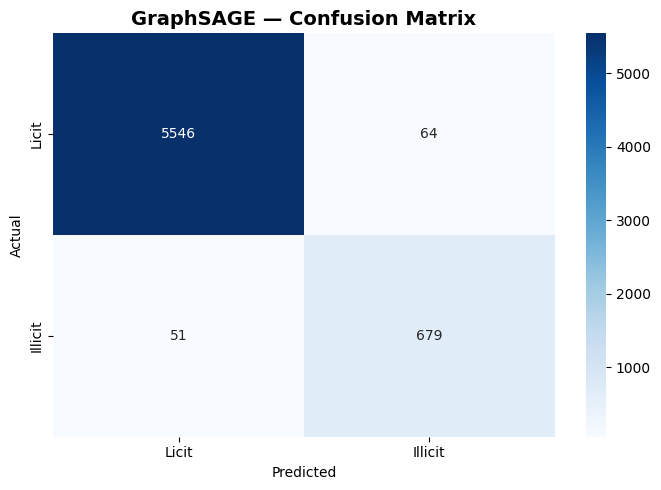


 BUSINESS METRICS — GraphSAGE:
   Fraud Recall (caught)   : 93.0%
   False Positive Rate     : 1.1%
   Fraud cases detected    : 679 / 730


In [21]:

model.load_state_dict(torch.load('best_model.pt'))


f1, pr_auc, true, pred = evaluate(data.test_mask)

print("=" * 55)
print("           GRAPHSAGE — FINAL RESULTS")
print("=" * 55)
print(f"\nPRIMARY METRICS:")
print(f"   Macro F1 Score  : {f1:.4f}")
print(f"   PR-AUC Score    : {pr_auc:.4f}")

print(f"\n DETAILED CLASSIFICATION REPORT:")
print(classification_report(true, pred,
                              target_names=['Licit', 'Illicit'],
                              digits=4))

# Confusion Matrix
cm = confusion_matrix(true, pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Licit', 'Illicit'],
            yticklabels=['Licit', 'Illicit'])
plt.title('GraphSAGE — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_gnn.png', dpi=150)
plt.show()

print_business_metrics('GraphSAGE', true, pred)

## 8) Final comparison

The same test split is used for all four models.
The results are lined up in the same order they were trained: XGBoost, GCN, GAT, then GraphSAGE.
That keeps the comparison honest and makes the progression from simple to graph-aware obvious.


 XGBoost               →  F1: 0.9871  |  PR-AUC: 0.9942
   GCN                    →  F1: 0.8784  |  PR-AUC: 0.8684
   GAT                    →  F1: 0.8012  |  PR-AUC: 0.8909
   GraphSAGE              →  F1: 0.9558  |  PR-AUC: 0.9692


        FINAL COMPARISON — All 4 Models
Model                    Macro F1       PR-AUC    F1 Rank   AUC Rank
XGBoost (No Graph)         0.9871       0.9942         #1         #1
GCN                        0.8784       0.8684         #3         #4
GAT                        0.8012       0.8909         #4         #3
GraphSAGE                  0.9558       0.9692         #2         #2

Best Macro F1  : XGBoost (No Graph)
best PR-AUC    : XGBoost (No Graph)

 BUSINESS METRICS SUMMARY:
    Model  Fraud Recall (%)  False Positive Rate (%) Fraud cases detected
  XGBoost              96.7                      0.2            706 / 730
      GCN              87.3                      4.5            637 / 730
      GAT              96.2                     11.9     

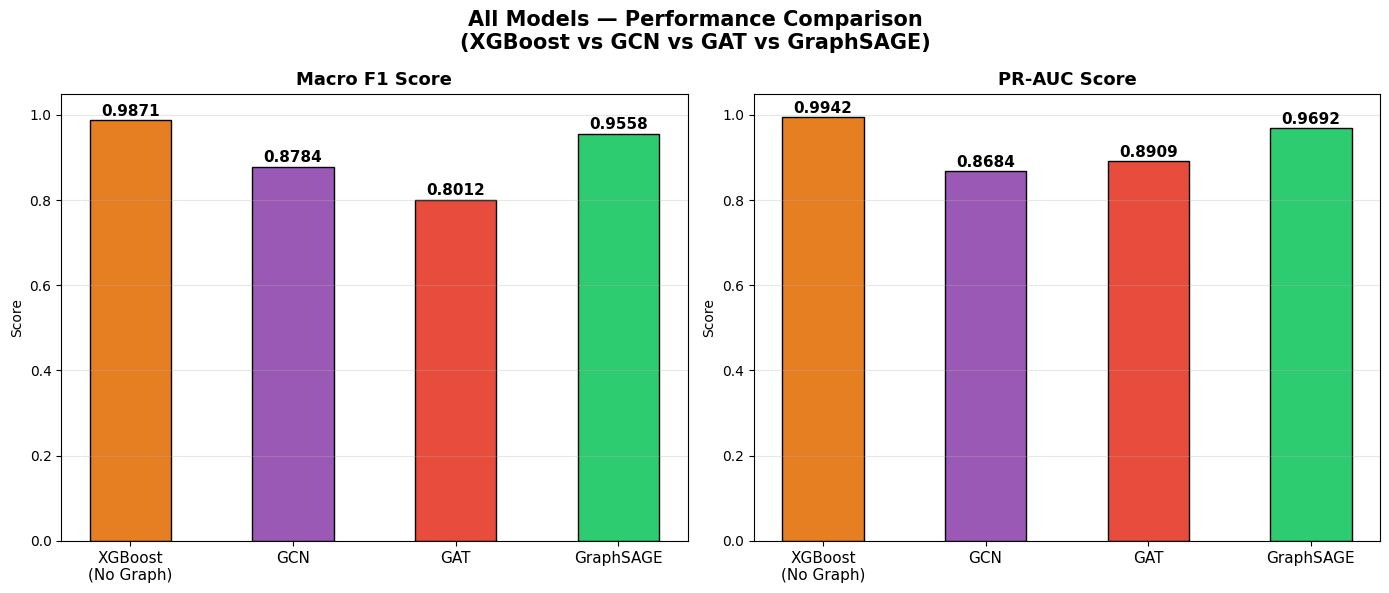

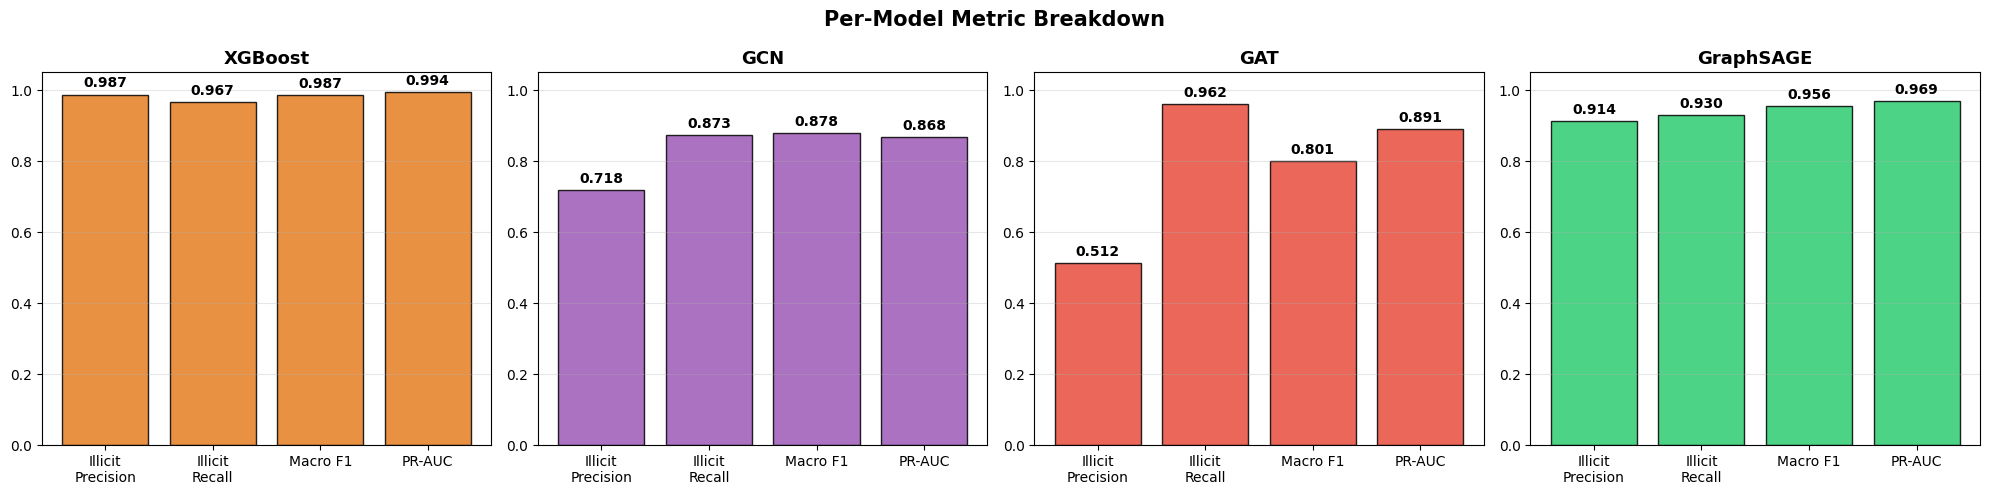

In [22]:


from sklearn.metrics import precision_score, recall_score
import matplotlib.patches as mpatches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sage_model = GraphSAGE(
    in_channels  = data.num_node_features,
    hidden1      = 256,
    hidden2      = 128,
    out_channels = 2,
    dropout      = 0.3
).to(device)
sage_model.load_state_dict(torch.load('best_model.pt'))
sage_model.eval()

with torch.no_grad():
    out          = sage_model(data.x, data.edge_index)
    sage_preds   = out.argmax(dim=1)
    sage_probs   = F.softmax(out, dim=1)[:, 1]
    sage_true    = data.y[data.test_mask].detach().cpu().numpy()
    sage_pred    = sage_preds[data.test_mask].detach().cpu().numpy()
    sage_prob    = sage_probs[data.test_mask].detach().cpu().numpy()

sage_f1_final    = f1_score(sage_true, sage_pred, average='macro', zero_division=0)
sage_prauc_final = average_precision_score(sage_true, sage_prob)

print(f" XGBoost               →  F1: {xgb_f1:.4f}  |  PR-AUC: {xgb_prauc:.4f}")
print(f"   GCN                    →  F1: {gcn_f1_final:.4f}  |  PR-AUC: {gcn_prauc_final:.4f}")
print(f"   GAT                    →  F1: {gat_f1_final:.4f}  |  PR-AUC: {gat_prauc_final:.4f}")
print(f"   GraphSAGE              →  F1: {sage_f1_final:.4f}  |  PR-AUC: {sage_prauc_final:.4f}")


def get_full_metrics(true_arr, pred_arr, prob_arr):
    p   = precision_score(true_arr, pred_arr, pos_label=1, zero_division=0)
    r   = recall_score(true_arr,    pred_arr, pos_label=1, zero_division=0)
    mf1 = f1_score(true_arr,        pred_arr, average='macro', zero_division=0)
    auc = average_precision_score(true_arr, prob_arr)
    return p, r, mf1, auc

gcn_model.eval()
with torch.no_grad():
    gcn_probs_arr = F.softmax(gcn_model(data.x, data.edge_index), dim=1)[:, 1][data.test_mask].detach().cpu().numpy()

gat_model.eval()
with torch.no_grad():
    gat_probs_arr = F.softmax(gat_model(data.x, data.edge_index), dim=1)[:, 1][data.test_mask].detach().cpu().numpy()


all_metrics = {
    'XGBoost':   get_full_metrics(y_test,    xgb_pred,  xgb_prob),
    'GCN':       get_full_metrics(gcn_true,  gcn_pred,  gcn_probs_arr),
    'GAT':       get_full_metrics(gat_true,  gat_pred,  gat_probs_arr),
    'GraphSAGE': get_full_metrics(sage_true, sage_pred, sage_prob),
}

results = {
    'XGBoost\n(No Graph)': {'f1': xgb_f1,          'prauc': xgb_prauc,       'color': '#e67e22'},
    'GCN':                  {'f1': gcn_f1_final,     'prauc': gcn_prauc_final, 'color': '#9b59b6'},
    'GAT':                  {'f1': gat_f1_final,     'prauc': gat_prauc_final, 'color': '#e74c3c'},
    'GraphSAGE':            {'f1': sage_f1_final,    'prauc': sage_prauc_final,'color': '#2ecc71'},
}

sorted_by_f1    = sorted(results.items(), key=lambda x: x[1]['f1'],    reverse=True)
sorted_by_prauc = sorted(results.items(), key=lambda x: x[1]['prauc'], reverse=True)
f1_rank    = {m: i+1 for i, (m, _) in enumerate(sorted_by_f1)}
prauc_rank = {m: i+1 for i, (m, _) in enumerate(sorted_by_prauc)}

print("\n")
print("=" * 68)
print("        FINAL COMPARISON — All 4 Models")
print("=" * 68)
print(f"{'Model':<20} {'Macro F1':>12} {'PR-AUC':>12} {'F1 Rank':>10} {'AUC Rank':>10}")


for model_name, vals in results.items():
    label = model_name.replace('\n', ' ')
    print(f"{label:<20} {vals['f1']:>12.4f} {vals['prauc']:>12.4f}"
          f" {'#'+str(f1_rank[model_name]):>10} {'#'+str(prauc_rank[model_name]):>10}")


best_f1_model    = max(results, key=lambda m: results[m]['f1']).replace('\n', ' ')
best_prauc_model = max(results, key=lambda m: results[m]['prauc']).replace('\n', ' ')
print(f"\nBest Macro F1  : {best_f1_model}")
print(f"best PR-AUC    : {best_prauc_model}")

business_summary = []
for model_name, true_arr, pred_arr in [
    ('XGBoost', y_test, xgb_pred),
    ('GCN', gcn_true, gcn_pred),
    ('GAT', gat_true, gat_pred),
    ('GraphSAGE', sage_true, sage_pred),
]:
    m = business_metrics_from_predictions(true_arr, pred_arr)
    business_summary.append({
        'Model': model_name,
        'Fraud Recall (%)': round(m['fraud_recall'] * 100, 1),
        'False Positive Rate (%)': round(m['false_positive_rate'] * 100, 1),
        'Fraud cases detected': f"{m['fraud_detected']} / {m['fraud_total']}",
    })

business_df = pd.DataFrame(business_summary)
print("\n BUSINESS METRICS SUMMARY:")
print(business_df.to_string(index=False))

model_labels = [m.replace('\n', '\n') for m in results]
f1_vals      = [v['f1']    for v in results.values()]
prauc_vals   = [v['prauc'] for v in results.values()]
colors       = [v['color'] for v in results.values()]
x            = range(len(model_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('All Models — Performance Comparison\n(XGBoost vs GCN vs GAT vs GraphSAGE)',
             fontsize=15, fontweight='bold')

for ax, vals, title in zip(axes, [f1_vals, prauc_vals], ['Macro F1 Score', 'PR-AUC Score']):
    bars = ax.bar(x, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01, f'{val:.4f}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('final_4model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


metric_names  = ['Illicit\nPrecision', 'Illicit\nRecall', 'Macro F1', 'PR-AUC']
model_colors  = ['#e67e22', '#9b59b6', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Per-Model Metric Breakdown', fontsize=15, fontweight='bold')

for ax, (model_name, vals), col in zip(axes, all_metrics.items(), model_colors):
    bars = ax.bar(metric_names, vals, color=col, edgecolor='black', alpha=0.85)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.02, f'{val:.3f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('per_model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
